# Titanic Survival Prediction using Logistic Regression
**Name:** Anshul Singh Jadon

**Rollno.:**  2301920100064

**Topic:** Binary Classification using Logistic Regression


## 0. Setup: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc, roc_auc_score)


import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)


## Part 1: Understanding the Dataset



In [3]:
df_raw = pd.read_csv('C:\\Users\\ANSHUL SINGH JADON\\Desktop\\AI ML\\datas\\train_and_test2.csv')
print("Raw shape:", df_raw.shape)
df_raw.head(10)

Raw shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
5,6,28.0,8.4583,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1.0,0,0,0
6,7,54.0,51.8625,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,0
7,8,2.0,21.0750,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
8,9,27.0,11.1333,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
9,10,14.0,30.0708,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0.0,0,0,1


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.13      1309

In [5]:
# Drop junk zero* columns and rename the target column
zero_cols = [c for c in df_raw.columns if c.startswith('zero')]
df = df_raw.drop(columns=zero_cols, errors='ignore').copy()
df = df.rename(columns={'2urvived': 'Survived', 'sibsp': 'SibSp'})

print('Cleaned shape:', df.shape)
df.head(10)


Cleaned shape: (1309, 9)


,Passengerid,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
5,6,28.0,8.4583,0,0,0,3,1.0,0
6,7,54.0,51.8625,0,0,0,1,2.0,0
7,8,2.0,21.0750,0,3,1,3,2.0,0
8,9,27.0,11.1333,1,0,2,3,2.0,1
9,10,14.0,30.0708,1,1,0,2,0.0,1


In [6]:
print("Dimensions:", df.shape)
print(df.isnull().sum())

Dimensions: (1309, 9)
Passengerid    0
Age            0
Fare           0
Sex            0
SibSp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


In [7]:
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Pclass', 'Embarked']
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

df.describe()

Numerical features: ['Age', 'Fare', 'SibSp', 'Parch']
Categorical features: ['Sex', 'Pclass', 'Embarked']


,Passengerid,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


## Part 2: Exploratory Data Analysis (EDA)

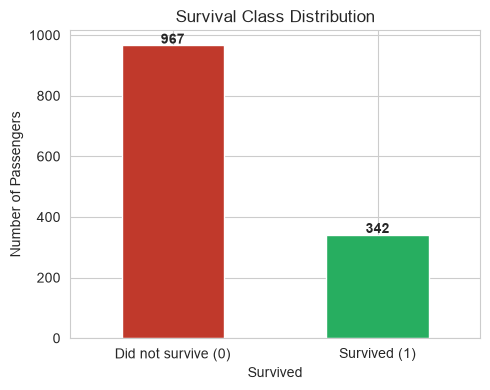

Survived
0    967
1    342 
Survival rate: 0.261


In [8]:
counts = df['Survived'].value_counts().sort_index()
counts.plot(kind='bar', color=['#c0392b', '#27ae60'], figsize=(5,4), rot=0)
plt.title('Survival Class Distribution')
plt.ylabel('Number of Passengers')
plt.xticks([0,1], ['Did not survive (0)', 'Survived (1)'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, v, ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(counts.to_string(), f"\nSurvival rate: {df['Survived'].mean():.3f}")

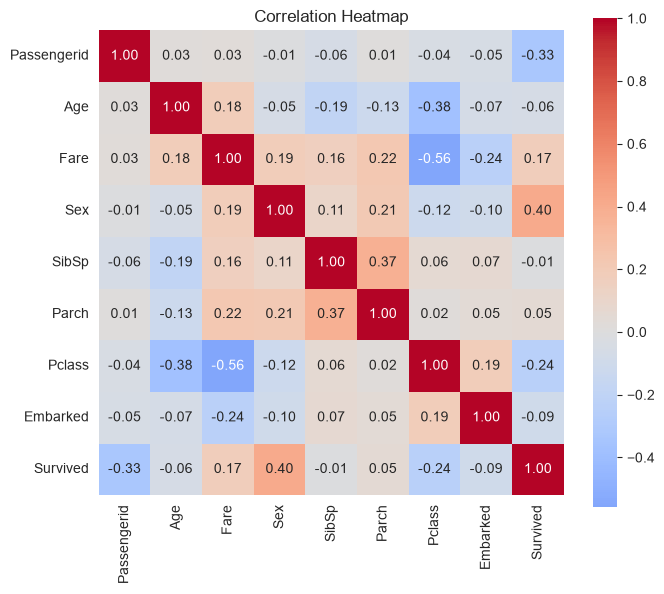

Sex            0.404020
Fare           0.173786
Parch          0.054908
SibSp         -0.014375
Age           -0.055862
Embarked      -0.093225
Pclass        -0.244686
Passengerid   -0.331493
Name: Survived, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(7,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()
corr['Survived'].drop('Survived').sort_values(ascending=False)

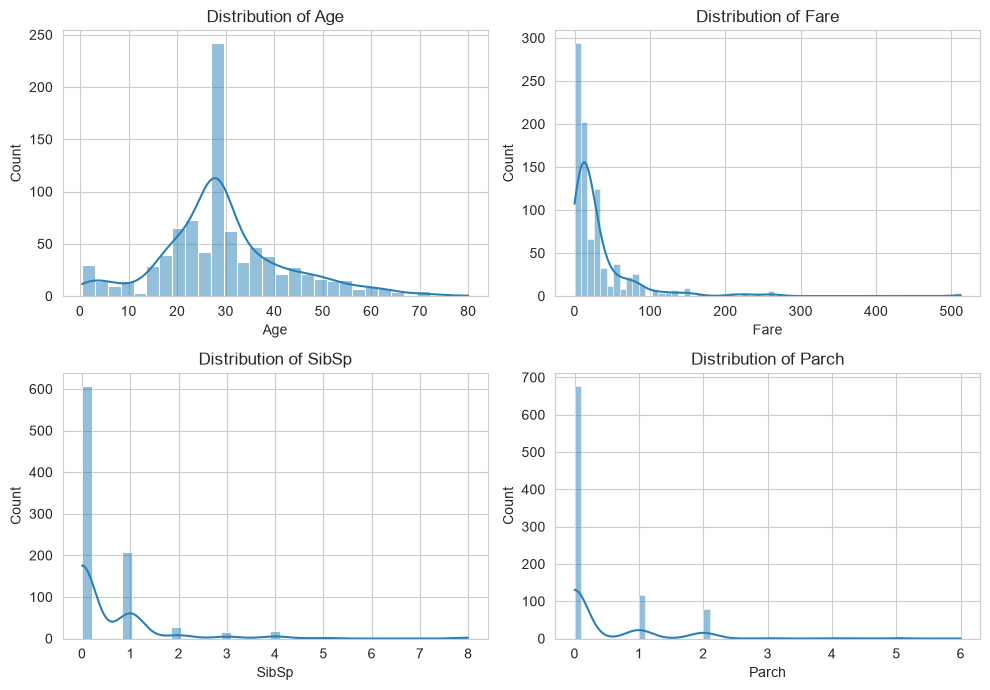

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10,7))
for ax, col in zip(axes.flat, numerical_features):
    sns.histplot(df[col], kde=True, ax=ax, color='#2980b9')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout(); plt.show()

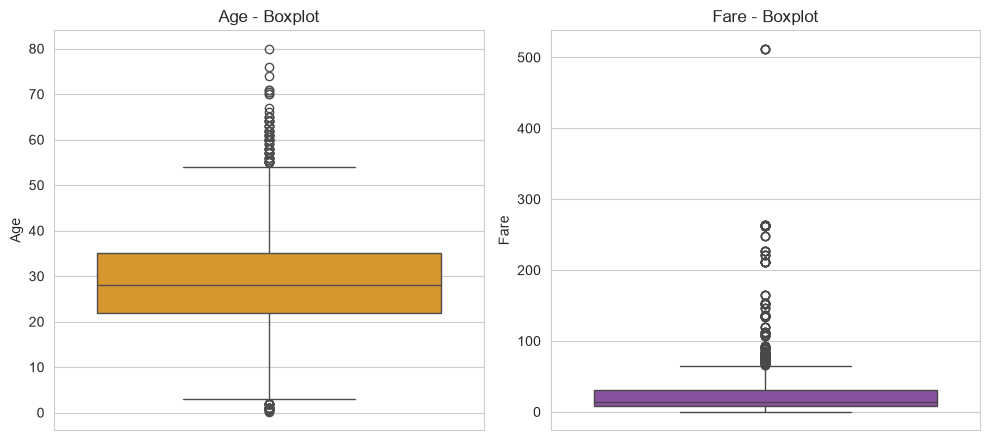

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
sns.boxplot(y=df['Age'], ax=axes[0], color='#f39c12'); axes[0].set_title('Age - Boxplot')
sns.boxplot(y=df['Fare'], ax=axes[1], color='#8e44ad'); axes[1].set_title('Fare - Boxplot')
plt.tight_layout(); plt.show()



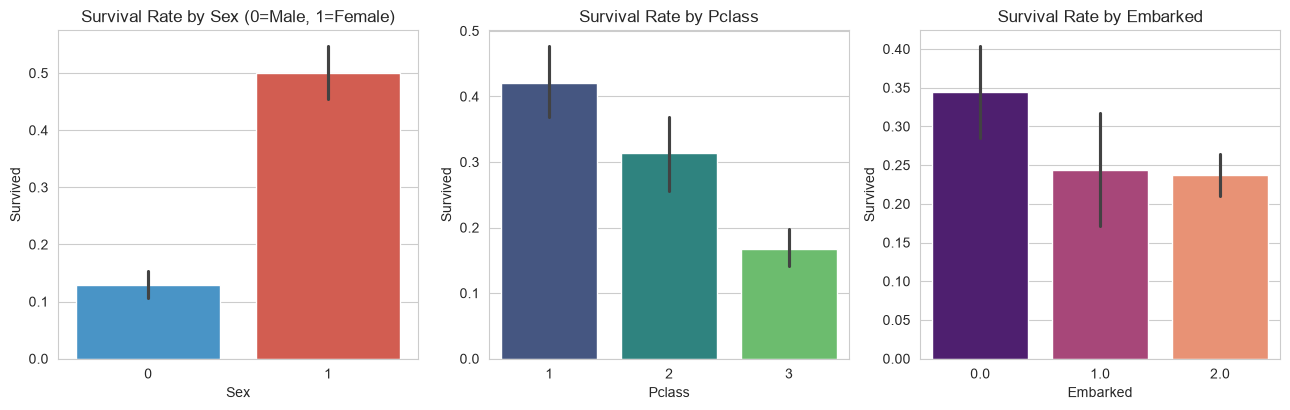

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette=['#3498db','#e74c3c'])
axes[0].set_title('Survival Rate by Sex (0=Male, 1=Female)')
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Survival Rate by Pclass')
sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Survival Rate by Embarked')
plt.tight_layout(); plt.show()


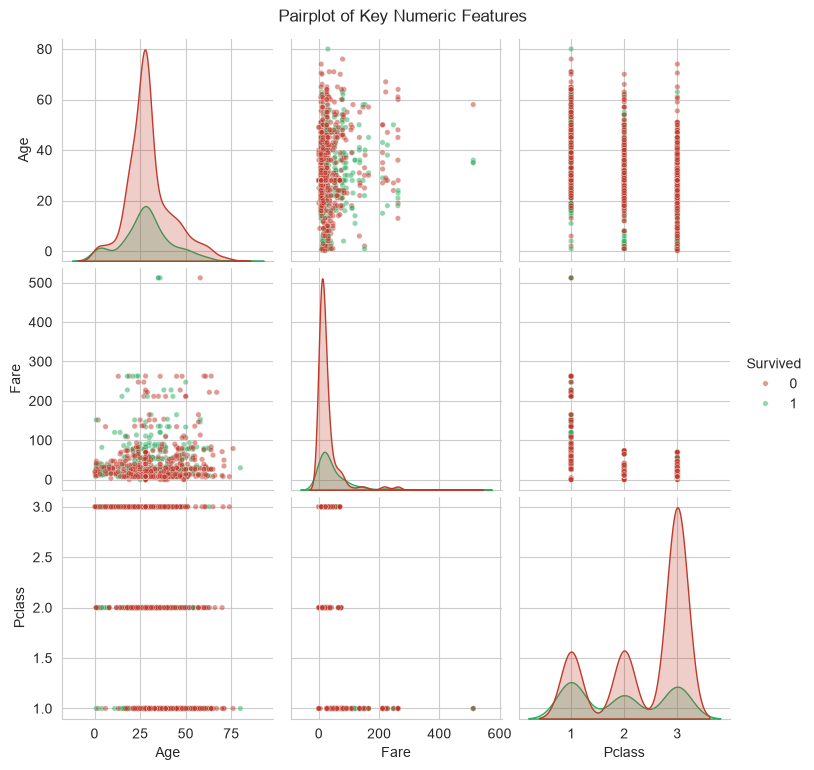

In [12]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']].dropna(), hue='Survived',
             palette={0:'#c0392b',1:'#27ae60'}, plot_kws={'alpha':0.5, 's':15})
plt.suptitle('Pairplot of Key Numeric Features', y=1.02)
plt.show()

## Part 3: Data Preprocessing



In [13]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Passengerid    0
Age            0
Fare           0
Sex            0
SibSp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


In [14]:
df_model = pd.get_dummies(df, columns=['Pclass', 'Embarked'], drop_first=True)

X = df_model.drop(columns=['Survived', 'Passengerid'])
y = df_model['Survived']
print("Feature columns:", list(X.columns))
X.head()

Feature columns: ['Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass_2', 'Pclass_3', 'Embarked_1.0', 'Embarked_2.0']


,Age,Fare,Sex,SibSp,Parch,Pclass_2,Pclass_3,Embarked_1.0,Embarked_2.0
0,22.0,7.2500,0,1,0,False,True,False,True
1,38.0,71.2833,1,1,0,False,False,False,False
2,26.0,7.9250,1,0,0,False,True,False,True
3,35.0,53.1000,1,1,0,False,False,False,True
4,35.0,8.0500,0,0,0,False,True,False,True


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (1047, 9) Test shape: (262, 9)


## Part 4: Logistic Regression Model

In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

print("Intercept:", round(logreg.intercept_[0], 4))
coef_series = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:")
print(coef_series.round(4))

Intercept: -1.345

Coefficients:
Sex             0.9236
Pclass_3       -0.8459
Age            -0.4123
Pclass_2       -0.2650
SibSp          -0.1575
Embarked_2.0   -0.0693
Fare           -0.0399
Parch          -0.0138
Embarked_1.0   -0.0048
dtype: float64


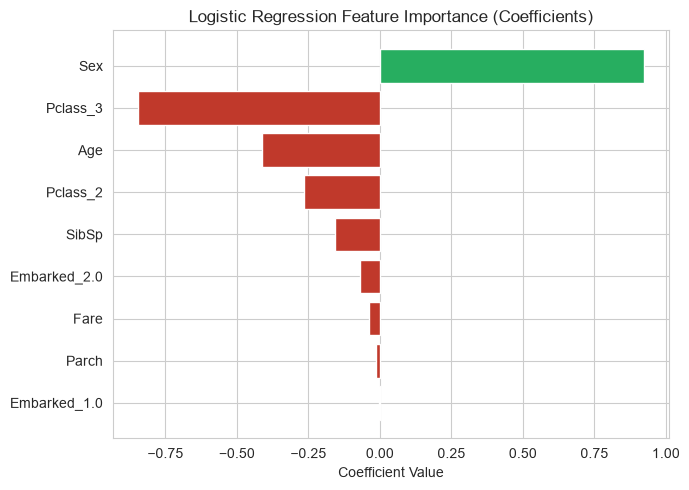

In [18]:
fig, ax = plt.subplots(figsize=(7,5))
colors = ['#27ae60' if v > 0 else '#c0392b' for v in coef_series.values]
ax.barh(coef_series.index[::-1], coef_series.values[::-1], color=colors[::-1])
ax.set_title('Logistic Regression Feature Importance (Coefficients)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

## Part 5: Model Evaluation

In [19]:
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_val = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc_val:.4f}")

Accuracy : 0.7443
Precision: 0.5106
Recall   : 0.3529
F1 Score : 0.4174
ROC-AUC  : 0.7572


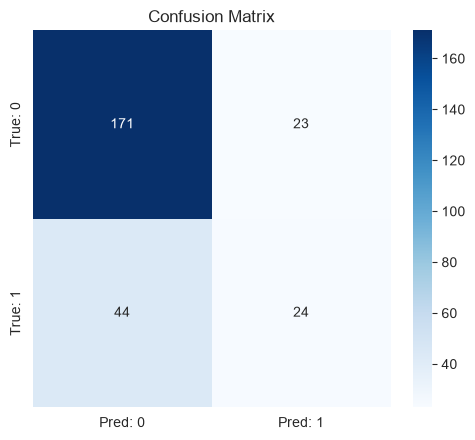

In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: 0','Pred: 1'], yticklabels=['True: 0','True: 1'])
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()



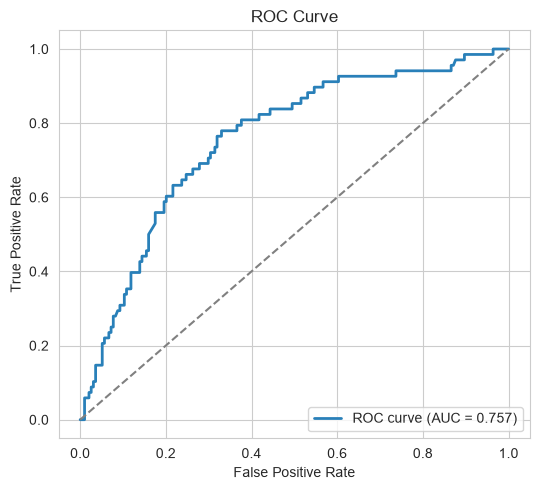

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## Part 6: Hyperparameter Tuning (GridSearchCV)

In [23]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 score:", round(grid.best_score_, 4))

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 score: 0.5612


In [24]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print("Tuned Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Tuned Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Tuned Recall   :", round(recall_score(y_test, y_pred_tuned), 4))
print("Tuned F1       :", round(f1_score(y_test, y_pred_tuned), 4))

Tuned Accuracy : 0.7557
Tuned Precision: 0.54
Tuned Recall   : 0.3971
Tuned F1       : 0.4576
